# [LAB-06] 6. Violin Plot - 연습문제

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
import seaborn as sb
from pandas import concat

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data("cookie_cats")
origin.head()

📚 어느 모바일 게임의 버전에 따른 유저별 총 플레이 시간을 조사한 데이터 (출처: 방송통신대학교 통계학개론)


,version,sum_gamerounds
userid,,
116,A,3
337,A,38
377,B,165
483,B,1
488,B,179


## 요구사항 처리

다음 순서대로 작업을 수행하여 버전별 바이올린 플롯을 완성하시오.

1. `version` 컬럼을 기준으로 데이터를 A 버전과 B 버전으로 분리하여 각각의 DataFrame으로 저장한다.
2. A 버전 데이터의 기술 통계량을 구하여 이상치 경계값(상한, 하한)을 확인한다.
3. A 버전 데이터에서 이상치 경계 안쪽에 해당하는 행만 남도록 필터링한다.
4. B 버전 데이터에 대해서도 2 ~ 3번 과정을 동일하게 수행하여 이상치를 제거한다.
5. 이상치를 제거한 A, B 데이터를 하나의 DataFrame으로 세로 병합한다.
6. 병합한 데이터로 버전(`version`)을 색상으로 구분하는 바이올린 플롯을 그린다. (y축: 총 플레이 시간, 제목·축 라벨 지정)

### 1. 버전별 데이터 분리

In [3]:
df_a = df1[df1["version"] == "A"]
df_b = df1[df1["version"] == "B"]

display(df_a.head())
display(df_b.head())

NameError: name 'df1' is not defined

### 2. A 버전에 대한 이상치 제거

#### 1) 기술 통계량 확인

- 이상치 경계값을 위함

In [ ]:
desc_df = my_qtcheck.numerical_summary(df_a)
desc_df

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
sum_gamerounds,44700.000,52.456,256.716,0.000,5.000,17.000,50.000,49854.000,2.086,large_diff,45.000,117.500,-62.500,5207,0.116,0,0.000,5207,0.116,163.710,right tail,31688.381,leptokurtic,log1p


#### 2) A 버전에 대해 이상치를 제거

- 이상치 구간 내의 데이터만 필터링하면 됨

In [ ]:
df_a_qt = df_a[(df_a['sum_gamerounds'] >= desc_df['lower_bound']['sum_gamerounds']) & (df_a['sum_gamerounds'] <= desc_df['upper_bound']['sum_gamerounds'])]
df_a_qt

,version,sum_gamerounds
userid,,
116,A,3
337,A,38
1066,A,0
2101,A,0
2179,A,39
...,...,...
9998576,A,14
9998623,A,7
9999178,A,21


### 3. B 버전에 대한 이상치 제거

In [ ]:
desc_df = my_qtcheck.numerical_summary(df_b)

df_b_qt = df_b[(df_b['sum_gamerounds'] >= desc_df['lower_bound']['sum_gamerounds']) & (df_b['sum_gamerounds'] <= desc_df['upper_bound']['sum_gamerounds'])]
df_b_qt

,version,sum_gamerounds
userid,,
483,B,1
1444,B,2
1574,B,108
1842,B,3
2132,B,30
...,...,...
9998733,B,10
9999441,B,97
9999479,B,30


### 4. 세로 병합

In [ ]:
df_qtcheck = concat([df_a_qt, df_b_qt], ignore_index=True)
df_qtcheck.head()

,version,sum_gamerounds
0,A,3
1,A,38
2,A,0
3,A,0
4,A,39


### 5. 버전별 바이올린 플롯 시각화

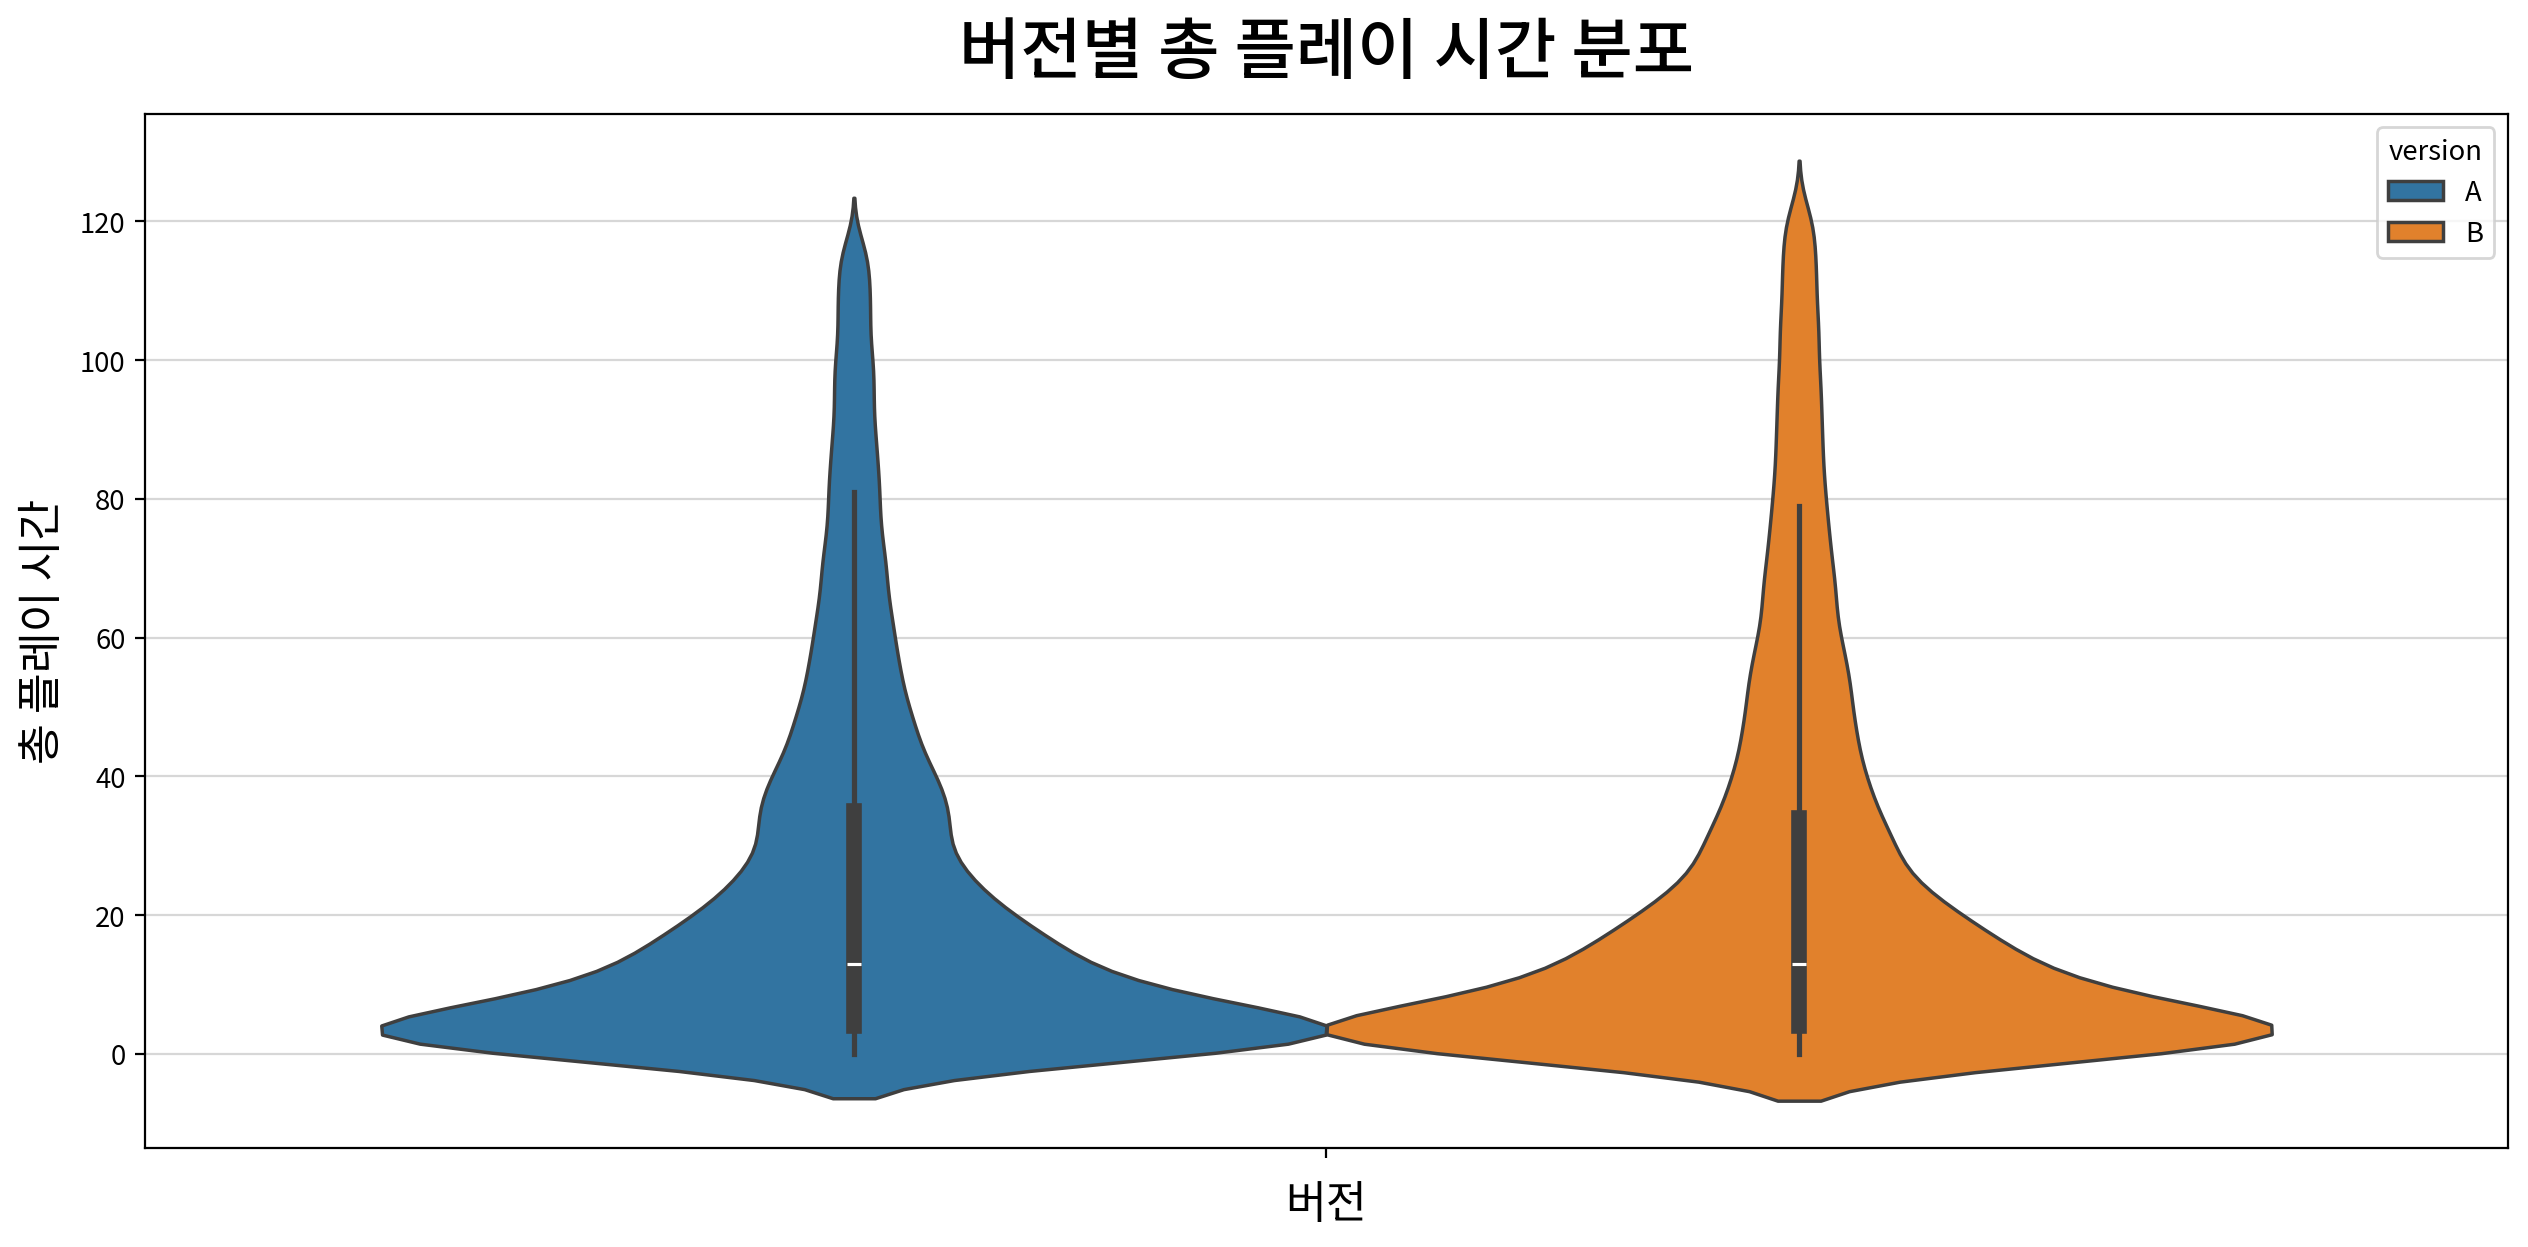

In [ ]:
my_plot.violinplot(df_qtcheck, hue="version", y="sum_gamerounds", title="버전별 총 플레이 시간 분포", xlabel="버전", ylabel="총 플레이 시간")

## 문제 풀이

### 문제 1

두 버전의 바이올린 플롯에서 가로 두께(밀도)가 가장 두껍게 나타나는 플레이 시간 구간은 어디인가?

- **정답**: 약 0 ~ 10회
- **해설**: 바이올린 플롯의 가로 폭은 해당 값 구간에 속하는 데이터의 밀도(빈도)를 의미한다. A 버전과 B 버전 모두 0 ~ 10회 부근에서 가장 두꺼운 폭을 보이고 있어, 두 버전 모두 대다수의 유저가 게임을 거의 하지 않았거나 10회 이내로 매우 적게 플레이한 뒤 이탈했음을 알 수 있다. 이는 모바일 게임에서 흔히 관찰되는 초기 이탈 유저 패턴이다.

### 문제 2

두 버전의 바이올린 모양(아래는 두껍고 위로 갈수록 길고 가늘게 뻗는 형태)을 통해 알 수 있는 분포의 비대칭 방향(왜도)은?

- **정답**: 우측(양의 왜도, right-skewed)
- **해설**: 두 바이올린 모두 낮은 값(0 부근)에서 폭이 매우 넓고 높은 값으로 갈수록 폭이 좁아지면서 길게 꼬리를 형성하고 있다. 이는 분포가 오른쪽으로 긴 꼬리를 갖는 양의 왜도(positively skewed) 형태임을 의미한다. 즉 대다수 유저는 짧게 플레이하지만, 일부 소수의 유저가 매우 긴 플레이 시간을 기록하는 헤비 유저로 존재하여 평균을 끌어올리는 구조이다.

### 문제 3

A 버전과 B 버전의 바이올린(분포 모양, 중앙값, 박스 위치, 꼬리 길이)을 비교했을 때 두 버전의 플레이 시간 분포 관계는?

- **정답**: 거의 유사함 (큰 차이 없음)
- **해설**: 두 바이올린의 최대 밀도 위치(약 0~10회), 내부 박스의 위치와 길이, 중앙값(약 13~15회), 위쪽 꼬리의 도달 지점이 모두 매우 비슷하게 나타난다. 따라서 A/B 테스트 결과 게임 버전 변경(A → B)은 유저의 총 플레이 시간 분포에 의미 있는 변화를 만들어내지 못했다고 해석할 수 있으며, 시각화만으로는 두 버전 간 유의미한 차이가 관찰되지 않는다.

### 문제 4

A → B 버전업이 유저의 플레이 시간 증가에 유의미한 영향을 주었다고 볼 수 있는가?

- **정답**: 아니오 (유의미한 영향 없음)
- **해설**: 바이올린 플롯에서 두 버전의 분포 형태, 중앙값(약 13 ~ 15회), 박스(IQR) 위치와 길이, 꼬리의 도달 지점이 모두 거의 동일하게 나타난다. 즉 B 버전이 A 버전 대비 분포 전체가 위쪽(플레이 시간이 큰 방향)으로 이동했거나 박스 영역이 위로 올라간 현상이 보이지 않으므로, 버전업이 유저의 총 플레이 시간 증가에 유의미한 영향을 주었다고 해석할 근거는 시각화 결과에서 확인되지 않는다. (실제 결론을 위해서는 가설검정 등 통계적 검증을 함께 수행해야 한다.)
